# Task 1 — HSGP Phenological Model: Corn, Soybean & Winter Wheat NDVI

**Approach:** Model seasonal NDVI phenological curves for three major U.S. crop types
— **corn**, **soybean**, and **winter wheat** — using a **Hilbert Space Gaussian
Process (HSGP)** approximation (Riutort-Mayol et al., 2023), fit via **Stochastic
Variational Inference (SVI)** in NumPyro / JAX. The posterior predictive distribution
yields the mean phenological curve and interquartile-range (IQR) uncertainty bands.
Empirical spatial IQR (across pixels) is also computed from the raw data.

**Data:** Multi-year (2008–2025) weekly NDVI spatial means for CDL-masked crop pixels
in the U.S. Corn Belt, mapped to day-of-year via per-year NDVI metadata JSON sidecars.

**Why three crops?** Corn and soybean are the dominant Corn Belt row crops, but the
assignment asks to characterize NDVI signatures for major crop types *generally*
(not just those two). Winter wheat (CDL 24) provides a contrasting cool-season
phenology — fall planting, spring green-up, early-summer peak, and July harvest —
making it an ideal third comparison crop.

## Pipeline Overview

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                        END-TO-END ANALYSIS PIPELINE                        │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  1. DATA ACQUISITION           2. SPATIAL ALIGNMENT        3. CROP MASKING │
│  ┌──────────────────┐          ┌──────────────────┐       ┌──────────────┐ │
│  │ MODIS NDVI weekly │          │ Reproject CDL to │       │ Filter pixels│ │
│  │ composites (WMS)  │────────▶│ NDVI grid (EPSG: │──────▶│ to corn, soy,│ │
│  │ + CDL crop masks  │          │ 5070, 250 m)     │       │ & wheat only │ │
│  └──────────────────┘          └──────────────────┘       └──────┬───────┘ │
│                                                                  │         │
│  4. AGGREGATION                5. GP MODELING              6. OUTPUT       │
│  ┌──────────────────┐          ┌──────────────────┐       ┌──────────────┐ │
│  │ Per-week spatial  │          │ HSGP (SE kernel) │       │ Phenological │ │
│  │ mean + IQR by     │────────▶│ per crop via SVI; │──────▶│ curves +     │ │
│  │ crop & year → DOY │          │ posterior predict │       │ evaluation   │ │
│  └──────────────────┘          └──────────────────┘       └──────────────┘ │
│                                                                             │
│  Steps 1–2 are handled by the data-processing scripts (src/).              │
│  Steps 3–6 are performed in this notebook.                                 │
└─────────────────────────────────────────────────────────────────────────────┘
```

**Key design decisions:**
- **Three crop types** (corn, soybean, winter wheat) to contrast warm-season vs
  cool-season phenology.
- **Empirical spatial IQR** computed from raw pixel distributions, in addition to
  Bayesian posterior uncertainty from the HSGP.
- **Memory-efficient loading**: CDL is pre-filtered to target crop pixels before
  merging with NDVI; wide-format aggregation avoids costly long-format melt.

In [13]:
import gc
import json
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import pyarrow.parquet as pq
import yaml
from numpyro.contrib.hsgp.approximation import hsgp_squared_exponential
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

numpyro.set_host_device_count(1)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [14]:
_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents)
     if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root (needs requirements.txt + src/)")
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "task1_ndvi_analysis.yaml") as f:
    cfg = yaml.safe_load(f)

CORN = int(cfg["cdl"]["crop_classes"]["corn"])
SOY = int(cfg["cdl"]["crop_classes"]["soybean"])
WHEAT = int(cfg["cdl"]["crop_classes"]["winter_wheat"])
SEED = int(cfg.get("run", {}).get("seed", 42))
CROP_MAP = {"corn": CORN, "soy": SOY, "wheat": WHEAT}
print(f"JAX backend: {jax.default_backend()} | Corn={CORN}, Soy={SOY}, Wheat={WHEAT}, seed={SEED}")

JAX backend: cpu | Corn=1, Soy=5, Wheat=24, seed=42


## Data loading

For every calendar year with both a CDL column and an NDVI weekly Parquet on disk,
we merge CDL crop masks with NDVI, compute the **spatial mean, 25th-percentile, and
75th-percentile NDVI per week** for corn, soybean, and winter wheat pixels, and map
week indices to **day-of-year (DOY)** via the JSON sidecar metadata.

**Memory optimization:** The CDL is pre-filtered to only pixels that are one of the
three target crops in *any* year (~5–10 % of the full grid), dramatically reducing
the merge footprint. Aggregation operates directly on wide-format columns to avoid
a costly long-format melt.

In [ ]:
def discover_years(repo):
    cdl_pq = repo / "data" / "processed" / "cdl" / "cdl_stack_wide.parquet"
    names = pq.ParquetFile(cdl_pq).schema_arrow.names
    cdl_years = sorted(int(n.replace("cdl_", "")) for n in names if n.startswith("cdl_"))
    ndvi_dir = repo / "data" / "processed" / "ndvi"
    ndvi_years = set()
    for p in ndvi_dir.glob("ndvi_weekly_*_wide.parquet"):
        ndvi_years.add(int(p.stem.replace("ndvi_weekly_", "").replace("_wide", "")))
    return sorted(y for y in cdl_years if y in ndvi_years)

YEARS = discover_years(REPO_ROOT)
print(f"Years with both CDL + NDVI: {YEARS[0]}\u2013{YEARS[-1]} (n={len(YEARS)})")

cdl_path = REPO_ROOT / "data" / "processed" / "cdl" / "cdl_stack_wide.parquet"
cdl_cols = ["iy", "ix"] + [f"cdl_{y}" for y in YEARS]
cdl_df = pd.read_parquet(cdl_path, columns=cdl_cols)
print(f"CDL loaded: {len(cdl_df):,} pixels")

target_codes = set(CROP_MAP.values())
mask = pd.Series(False, index=cdl_df.index)
for y in YEARS:
    mask |= cdl_df[f"cdl_{y}"].isin(target_codes)
cdl_df = cdl_df[mask].reset_index(drop=True)
print(f"After crop filter: {len(cdl_df):,} pixels (target crops in \u22651 year)")

def load_ndvi_meta(year):
    p = REPO_ROOT / "data" / "processed" / "ndvi" / f"ndvi_weekly_{year}_metadata.json"
    return json.loads(p.read_text(encoding="utf-8")) if p.is_file() else None

records = []
for yi, y in enumerate(YEARS):
    ndvi_raw = pd.read_parquet(
        REPO_ROOT / "data" / "processed" / "ndvi" / f"ndvi_weekly_{y}_wide.parquet"
    )
    wcols = sorted([c for c in ndvi_raw.columns if c.startswith("w")])

    cdl_y = cdl_df[["iy", "ix", f"cdl_{y}"]].rename(columns={f"cdl_{y}": "crop_code"})
    merged = ndvi_raw.merge(cdl_y, on=["iy", "ix"], how="inner")
    del ndvi_raw

    meta = load_ndvi_meta(y)
    tsd = meta.get("time_start_day", []) if meta else []
    doy_map = {wi: pd.Timestamp(tsd[wi]).day_of_year for wi in range(len(tsd))}

    for crop_name, crop_code in CROP_MAP.items():
        sub = merged[merged["crop_code"] == crop_code]
        if sub.empty:
            continue
        for wi, wcol in enumerate(wcols):
            if wi not in doy_map:
                continue
            vals = sub[wcol].dropna()
            if vals.empty:
                continue
            records.append({
                "week": wi, "year": y, "crop": crop_name,
                "doy": doy_map[wi],
                "mean_ndvi": float(vals.mean()),
                "q25_ndvi": float(vals.quantile(0.25)),
                "q75_ndvi": float(vals.quantile(0.75)),
                "n_pixels": len(vals),
            })

    del merged
    gc.collect()
    if (yi + 1) % 6 == 0 or y == YEARS[-1]:
        print(f"  processed through {y} ({yi + 1}/{len(YEARS)})")

df = pd.DataFrame(records).dropna(subset=["doy", "mean_ndvi"])
df["doy"] = df["doy"].astype(int)

if df["mean_ndvi"].max() > 1.5:
    raw_max = df["mean_ndvi"].max()
    scale = 250.0 if raw_max <= 255 else 10000.0
    for col in ["mean_ndvi", "q25_ndvi", "q75_ndvi"]:
        df[col] /= scale
    print(f"Applied NDVI scale factor (/{scale:.0f})  [raw max was {raw_max:.1f}]")

print(f"\nTotal observations: {len(df)}")
print(f"NDVI range: [{df['mean_ndvi'].min():.4f}, {df['mean_ndvi'].max():.4f}]")
display(df.groupby("crop")["mean_ndvi"].describe().round(4))

Years with both CDL + NDVI: 2008–2025 (n=18)
CDL loaded: 48,208,677 pixels
After crop filter: 17,291,657 pixels (target crops in ≥1 year)


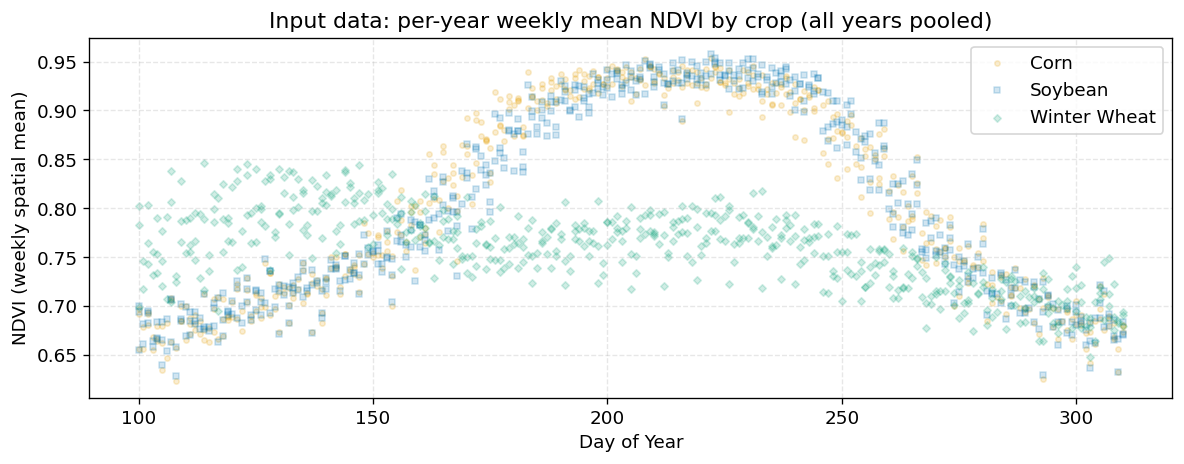

In [ ]:
CROP_STYLE = {
    "corn":  ("#E69F00", "o", "Corn"),
    "soy":   ("#0072B2", "s", "Soybean"),
    "wheat": ("#009E73", "D", "Winter Wheat"),
}

fig, ax = plt.subplots(figsize=(10, 4))
for crop, (color, mk, label) in CROP_STYLE.items():
    sub = df[df["crop"] == crop]
    ax.scatter(sub["doy"], sub["mean_ndvi"], alpha=0.18, s=10, color=color,
               marker=mk, label=label)
ax.set(xlabel="Day of Year", ylabel="NDVI (weekly spatial mean)",
       title="Input data: per-year weekly mean NDVI by crop (all years pooled)")
ax.legend()
ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

## HSGP Model

A separate HSGP model is fit independently to each of the three crop types. We model
the weekly spatial-mean NDVI as a smooth function of day-of-year using a
**Hilbert Space Gaussian Process** with a squared-exponential kernel:

$$\text{NDVI}(t) = \mu + f(t) + \varepsilon, \qquad
f \sim \mathcal{GP}\!\bigl(0,\; k_{\text{SE}}\bigr), \qquad
\varepsilon \sim \mathcal{N}(0, \sigma^2)$$

where $k_{\text{SE}}(t, t') = \alpha^2 \exp\!\left(-\frac{(t-t')^2}{2\ell^2}\right)$
and $f$ is approximated via $m = 25$ HSGP basis functions on a bounded domain
$[-L, L]$ with $L = 1.3 \max|t - \bar{t}|$.

**Priors:**

| Parameter | Prior | Motivation |
|-----------|-------|------------|
| $\mu$ (intercept) | $\mathcal{N}(0.65,\; 0.25)$ | Centers near mid-range physical NDVI |
| $\alpha$ (amplitude) | $\text{HalfNormal}(0.4)$ | Seasonal swing (base → peak ≈ 0.3–0.5) |
| $\ell$ (length-scale) | $\text{LogNormal}(\ln 25,\; 0.5)$ | ~3–4 week feature scale |
| $\sigma$ (noise) | $\text{HalfNormal}(0.1)$ | Inter-annual spread at same DOY |

**Inference:** SVI with a mean-field normal guide (`AutoNormal`), Adam optimizer.
Separate model fits allow each crop to have its own length-scale and noise,
accommodating the very different phenological shapes (e.g., winter wheat peaks
much earlier and has a shorter growing season than corn or soybean).

In [ ]:
def make_hsgp_model(ell, m=25):
    def model(x, y=None):
        intercept = numpyro.sample("intercept", dist.Normal(0.65, 0.25))
        amplitude = numpyro.sample("amplitude", dist.HalfNormal(0.4))
        length_scale = numpyro.sample("length_scale",
                                      dist.LogNormal(jnp.log(25.0), 0.5))
        noise = numpyro.sample("noise", dist.HalfNormal(0.1))
        f = hsgp_squared_exponential(
            x, amplitude, length_scale, ell, m, non_centered=True,
        )
        mu = intercept + f
        numpyro.deterministic("mu", mu)
        numpyro.sample("obs", dist.Normal(mu, noise), obs=y)
    return model

W0411 21:43:26.024493  498752 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
python(50229) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████| 8000/8000 [00:05<00:00, 1547.95it/s, init loss: 6491.0454, avg. loss [7601-8000]: -1217.6898]


corn: final loss = -1219.20


100%|██████████| 8000/8000 [00:09<00:00, 843.40it/s, init loss: 6446.7729, avg. loss [7601-8000]: -1246.4661] 


soy: final loss = -1248.07


100%|██████████| 8000/8000 [00:08<00:00, 972.31it/s, init loss: 5538.0054, avg. loss [7601-8000]: -1154.5153] 


wheat: final loss = -1154.79


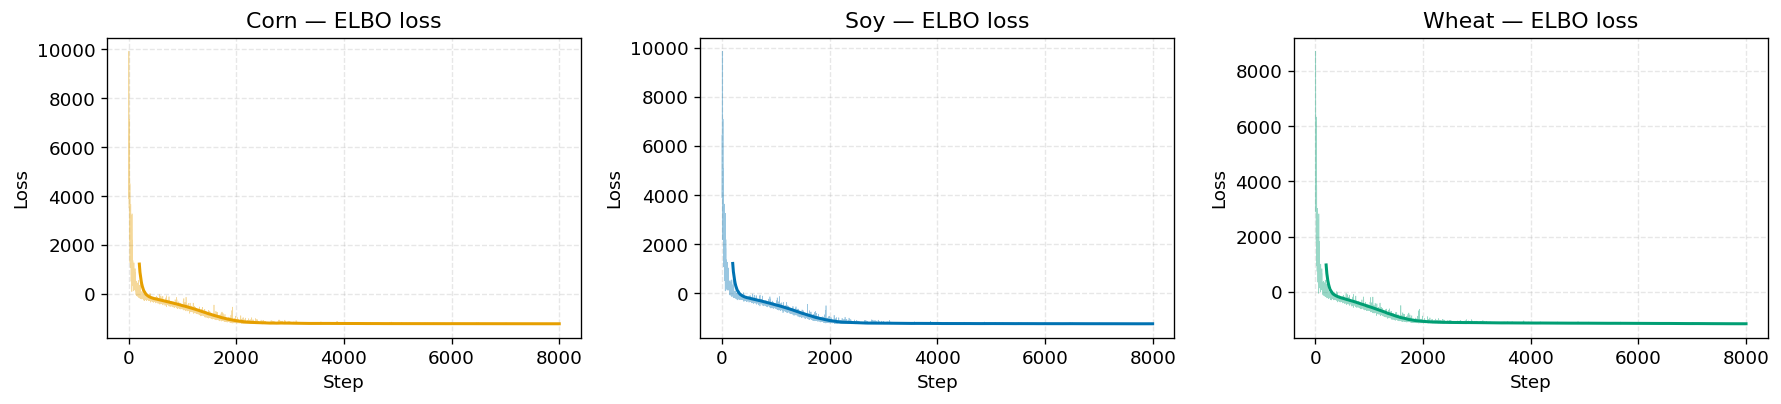

In [ ]:
def fit_hsgp_svi(model, x, y, num_steps=8000, lr=0.005, seed=42):
    guide = AutoNormal(model)
    svi = SVI(model, guide, Adam(step_size=lr), loss=Trace_ELBO())
    svi_result = svi.run(jr.PRNGKey(seed), num_steps, x, y=y, progress_bar=True)
    return svi_result, guide

CROP_COLORS = {"corn": "#E69F00", "soy": "#0072B2", "wheat": "#009E73"}
crop_names = list(CROP_COLORS.keys())

results = {}
fig, axes = plt.subplots(1, len(crop_names), figsize=(5 * len(crop_names), 3.5))

for idx, crop_name in enumerate(crop_names):
    color = CROP_COLORS[crop_name]
    crop_df = df[df["crop"] == crop_name]
    doy_vals = crop_df["doy"].values.astype(np.float64)
    ndvi_vals = crop_df["mean_ndvi"].values.astype(np.float64)

    doy_center = float((doy_vals.max() + doy_vals.min()) / 2)
    doy_c = doy_vals - doy_center
    ell = float(1.3 * np.max(np.abs(doy_c)))

    x_train = jnp.array(doy_c)
    y_train = jnp.array(ndvi_vals)

    model_fn = make_hsgp_model(ell=ell, m=25)
    svi_result, guide = fit_hsgp_svi(model_fn, x_train, y_train,
                                     num_steps=8000, seed=SEED)

    results[crop_name] = dict(
        svi_result=svi_result, guide=guide, model=model_fn,
        doy_center=doy_center, ell=ell,
        doy_raw=doy_vals, ndvi_raw=ndvi_vals,
    )

    ax = axes[idx]
    losses = np.array(svi_result.losses)
    ax.plot(losses, color=color, lw=0.4, alpha=0.4)
    w = min(200, len(losses) // 4)
    smoothed = np.convolve(losses, np.ones(w) / w, mode="valid")
    ax.plot(np.arange(w - 1, w - 1 + len(smoothed)), smoothed, color=color, lw=1.8)
    ax.set(title=f"{crop_name.capitalize()} \u2014 ELBO loss", xlabel="Step", ylabel="Loss")
    ax.grid(True, ls="--", alpha=0.3)
    print(f"{crop_name}: final loss = {losses[-1]:.2f}")

plt.tight_layout()
plt.show()

In [ ]:
predictions = {}
doy_lo, doy_hi = int(df["doy"].min()), int(df["doy"].max())
doy_grid = np.linspace(doy_lo - 3, doy_hi + 3, 300)

for crop_name, res in results.items():
    x_pred = jnp.array(doy_grid - res["doy_center"])
    predictive = Predictive(
        res["model"], guide=res["guide"], params=res["svi_result"].params,
        num_samples=2000, return_sites=["mu", "obs"],
    )
    ppc = predictive(jr.PRNGKey(SEED + 1), x_pred)
    mu_s = np.array(ppc["mu"])
    obs_s = np.array(ppc["obs"])

    crop_obs = df[df["crop"] == crop_name]
    predictions[crop_name] = dict(
        doy=doy_grid,
        mu_mean=mu_s.mean(0),
        mu_q25=np.percentile(mu_s, 25, axis=0),
        mu_q75=np.percentile(mu_s, 75, axis=0),
        obs_q05=np.percentile(obs_s, 5, axis=0),
        obs_q25=np.percentile(obs_s, 25, axis=0),
        obs_q75=np.percentile(obs_s, 75, axis=0),
        obs_q95=np.percentile(obs_s, 95, axis=0),
        emp_doy=crop_obs["doy"].values,
        emp_mean=crop_obs["mean_ndvi"].values,
        emp_q25=crop_obs["q25_ndvi"].values,
        emp_q75=crop_obs["q75_ndvi"].values,
    )
    pk = int(np.argmax(predictions[crop_name]["mu_mean"]))
    pk_doy = doy_grid[pk]
    pk_date = pd.Timestamp("2022-01-01") + pd.Timedelta(days=int(pk_doy) - 1)
    print(f"{crop_name}: peak NDVI = {predictions[crop_name]['mu_mean'][pk]:.3f} "
          f"at DOY {pk_doy:.0f} (~{pk_date:%b %d})")

corn: peak NDVI = 0.930 at DOY 204 (~Jul 22)
soy: peak NDVI = 0.938 at DOY 226 (~Aug 14)
wheat: peak NDVI = 0.804 at DOY 147 (~May 26)


## Phenological curves — main figure

All three crops are overlaid on one axis. **Solid lines** are the HSGP posterior mean;
the darker shaded band is the **posterior predictive IQR (25th–75th percentile)**,
and the lighter band is the 90 % credible interval. **Dashed lines** show the
**empirical spatial IQR** (25th and 75th percentile across pixels), capturing the
within-field variability that the Bayesian model smooths over. Scatter points are
the raw per-year weekly means that the model was fit to.

Saved → artifacts/figures/task1/hsgp_phenology_crops.png


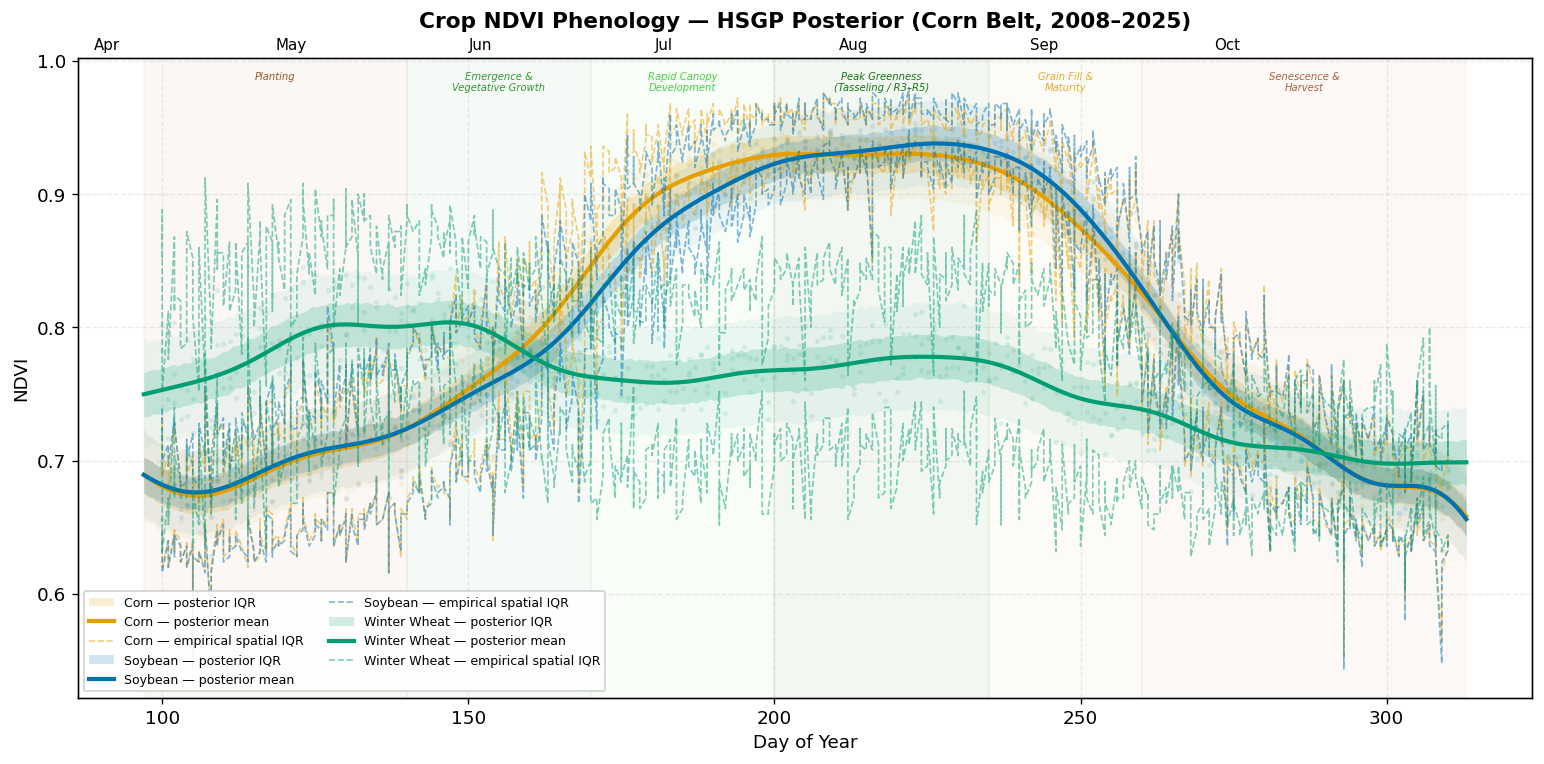

In [ ]:
PLOT_STYLE = {
    "corn":  ("#E69F00", "Corn"),
    "soy":   ("#0072B2", "Soybean"),
    "wheat": ("#009E73", "Winter Wheat"),
}

fig, ax = plt.subplots(figsize=(13, 6.5))

for crop, (color, label) in PLOT_STYLE.items():
    p = predictions[crop]
    r = results[crop]
    d = p["doy"]

    ax.fill_between(d, p["obs_q05"], p["obs_q95"],
                    alpha=0.06, color=color, lw=0)
    ax.fill_between(d, p["obs_q25"], p["obs_q75"],
                    alpha=0.18, color=color, lw=0,
                    label=f"{label} \u2014 posterior IQR")
    ax.plot(d, p["mu_mean"], color=color, lw=2.5,
            label=f"{label} \u2014 posterior mean")

    crop_df_emp = df[df["crop"] == crop].groupby("doy")[["q25_ndvi", "q75_ndvi"]].mean()
    emp_doy_agg = crop_df_emp.index.values
    ax.plot(emp_doy_agg, crop_df_emp["q25_ndvi"].values,
            color=color, lw=1.2, ls="--", alpha=0.6)
    ax.plot(emp_doy_agg, crop_df_emp["q75_ndvi"].values,
            color=color, lw=1.2, ls="--", alpha=0.6,
            label=f"{label} \u2014 empirical spatial IQR")

    ax.scatter(r["doy_raw"], r["ndvi_raw"], color=color,
               s=5, alpha=0.08, zorder=1)

stages = [
    (doy_lo - 3, 140, "Planting",                           "#8B4513", 0.04),
    (140,        170, "Emergence &\nVegetative Growth",      "#228B22", 0.04),
    (170,        200, "Rapid Canopy\nDevelopment",           "#32CD32", 0.03),
    (200,        235, "Peak Greenness\n(Tasseling / R3\u2013R5)", "#006400", 0.05),
    (235,        260, "Grain Fill &\nMaturity",              "#DAA520", 0.04),
    (260, doy_hi + 3, "Senescence &\nHarvest",              "#A0522D", 0.04),
]
ylo, yhi = ax.get_ylim()
for lo, hi, lbl, c, a in stages:
    ax.axvspan(lo, hi, alpha=a, color=c, zorder=0)
    ax.text((lo + hi) / 2, yhi - 0.02 * (yhi - ylo), lbl,
            ha="center", va="top", fontsize=6, color=c,
            fontstyle="italic", alpha=0.9)

ax.set(xlabel="Day of Year", ylabel="NDVI")
ax.set_title(
    f"Crop NDVI Phenology \u2014 HSGP Posterior "
    f"(Corn Belt, {YEARS[0]}\u2013{YEARS[-1]})",
    fontsize=13, fontweight="bold",
)
ax.legend(loc="lower left", fontsize=7.5, framealpha=0.9, ncol=2)
ax.grid(True, ls="--", alpha=0.25)

ax2 = ax.twiny()
month_doys = [(60, "Mar"), (91, "Apr"), (121, "May"), (152, "Jun"),
              (182, "Jul"), (213, "Aug"), (244, "Sep"), (274, "Oct")]
visible = [(d, m) for d, m in month_doys
           if ax.get_xlim()[0] - 5 <= d <= ax.get_xlim()[1] + 5]
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([d for d, _ in visible])
ax2.set_xticklabels([m for _, m in visible], fontsize=9)
ax2.tick_params(length=0)

plt.tight_layout()
out_dir = REPO_ROOT / cfg.get("output", {}).get("figures_dir", "artifacts/figures/task1/")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "hsgp_phenology_crops.png", dpi=200, bbox_inches="tight")
print(f"Saved \u2192 {(out_dir / 'hsgp_phenology_crops.png').relative_to(REPO_ROOT)}")
plt.show()

In [ ]:
rows = []
for crop, pred in predictions.items():
    for i, doy_val in enumerate(pred["doy"]):
        rows.append({
            "crop": crop,
            "doy": int(round(doy_val)),
            "posterior_mean": round(float(pred["mu_mean"][i]), 5),
            "posterior_iqr_25": round(float(pred["obs_q25"][i]), 5),
            "posterior_iqr_75": round(float(pred["obs_q75"][i]), 5),
            "ci_05": round(float(pred["obs_q05"][i]), 5),
            "ci_95": round(float(pred["obs_q95"][i]), 5),
        })
export_df = pd.DataFrame(rows)
tbl_dir = REPO_ROOT / cfg.get("output", {}).get("tables_dir", "artifacts/tables/task1/")
tbl_dir.mkdir(parents=True, exist_ok=True)
csv_path = tbl_dir / "hsgp_posterior_phenology.csv"
export_df.to_csv(csv_path, index=False)
print(f"Exported {csv_path.relative_to(REPO_ROOT)} ({len(export_df)} rows)")
display(export_df.head(8))

emp_csv = tbl_dir / "empirical_ndvi_by_crop.csv"
df.to_csv(emp_csv, index=False)
print(f"Exported {emp_csv.relative_to(REPO_ROOT)} ({len(df)} rows)")

Exported artifacts/tables/task1/hsgp_posterior_phenology.csv (900 rows)


,crop,doy,posterior_mean,posterior_iqr_25,posterior_iqr_75,ci_05,ci_95
0,corn,97,0.68947,0.67544,0.70311,0.65582,0.72564
1,corn,98,0.68716,0.67249,0.70136,0.65326,0.71976
2,corn,98,0.68498,0.67138,0.69909,0.65274,0.71867
3,corn,99,0.68295,0.66854,0.69627,0.64856,0.71407
4,corn,100,0.68109,0.66744,0.69497,0.64728,0.71394
5,corn,101,0.67941,0.66501,0.69261,0.64615,0.71152
6,corn,101,0.67794,0.66454,0.69224,0.64415,0.71209
7,corn,102,0.67667,0.66333,0.69072,0.64340,0.70813


Exported artifacts/tables/task1/empirical_ndvi_by_crop.csv (1605 rows)


## Year-by-year phenological features

To answer *"what phenological features best distinguish the crop types across years?"*
we extract per-year **peak DOY**, **peak NDVI**, and **greenup slope**
(NDVI increase rate from season start to peak) for each crop, then visualize
inter-annual variability.

Saved → artifacts/figures/task1/phenological_features_by_year.png


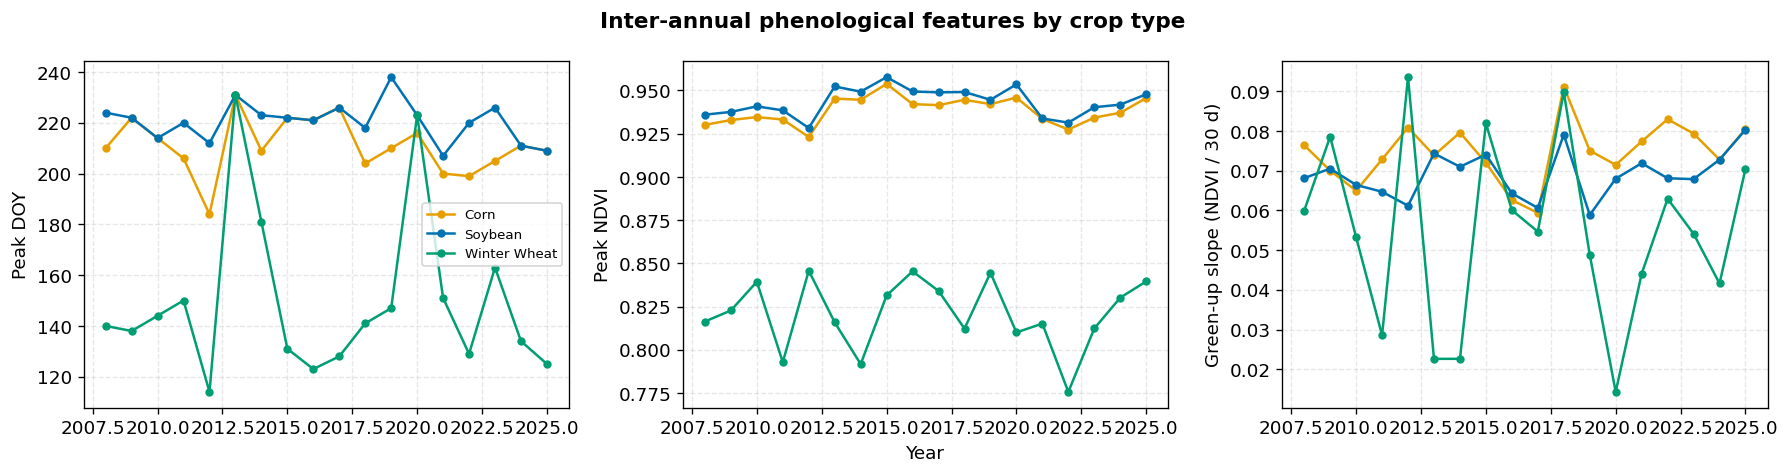


Phenological feature summary by crop:


peak_doy                                                        \
         count     mean     std    min     25%    50%     75%    max   
crop                                                                   
corn      18.0  211.056  11.154  184.0  205.25  210.0  219.75  231.0   
soy       18.0  220.389   7.792  207.0  215.00  221.5  223.75  238.0   
wheat     18.0  149.611  32.158  114.0  129.50  140.5  150.75  231.0   

      peak_ndvi         ...               greenup_slope_per30d                \
          count   mean  ...    75%    max                count   mean    std   
crop                    ...                                                    
corn       18.0  0.938  ...  0.945  0.954                 18.0  0.075  0.008   
soy        18.0  0.943  ...  0.949  0.958                 18.0  0.069  0.006   
wheat      18.0  0.821  ...  0.838  0.846                 18.0  0.055  0.023   

                                          
         min    25%    50%    75%    max  
crop                                      
corn   0.059  0.072  0.074  0.080  0.091  
soy    0.059  0.065  0.068  0.073  0.080  
wheat  0.014  0.042  0.054  0.069  0.094  

[3 rows x 24 columns]

In [ ]:
pheno_rows = []
for y in YEARS:
    for crop_name in CROP_MAP:
        sub = df[(df["year"] == y) & (df["crop"] == crop_name)].sort_values("doy")
        if sub.empty:
            continue
        peak_idx = sub["mean_ndvi"].idxmax()
        peak_doy = int(sub.loc[peak_idx, "doy"])
        peak_ndvi = float(sub.loc[peak_idx, "mean_ndvi"])

        pre_peak = sub[sub["doy"] <= peak_doy]
        if len(pre_peak) >= 2:
            d0, d1 = pre_peak["doy"].iloc[0], pre_peak["doy"].iloc[-1]
            n0, n1 = pre_peak["mean_ndvi"].iloc[0], pre_peak["mean_ndvi"].iloc[-1]
            greenup_slope = (n1 - n0) / max(d1 - d0, 1) * 30
        else:
            greenup_slope = np.nan

        pheno_rows.append({
            "year": y, "crop": crop_name,
            "peak_doy": peak_doy, "peak_ndvi": round(peak_ndvi, 4),
            "greenup_slope_per30d": round(greenup_slope, 5),
        })

pheno_df = pd.DataFrame(pheno_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
metrics = [
    ("peak_doy", "Peak DOY"),
    ("peak_ndvi", "Peak NDVI"),
    ("greenup_slope_per30d", "Green-up slope (NDVI / 30 d)"),
]
for ax, (col, ylabel) in zip(axes, metrics):
    for crop_name, (color, label) in PLOT_STYLE.items():
        sub = pheno_df[pheno_df["crop"] == crop_name]
        ax.plot(sub["year"], sub[col], "o-", color=color, label=label,
                markersize=4, lw=1.5)
    ax.set(ylabel=ylabel)
    ax.grid(True, ls="--", alpha=0.3)
axes[0].legend(fontsize=8)
axes[1].set(xlabel="Year")
fig.suptitle("Inter-annual phenological features by crop type",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out_dir = REPO_ROOT / cfg.get("output", {}).get("figures_dir", "artifacts/figures/task1/")
fig.savefig(out_dir / "phenological_features_by_year.png", dpi=200, bbox_inches="tight")
print(f"Saved \u2192 {(out_dir / 'phenological_features_by_year.png').relative_to(REPO_ROOT)}")
plt.show()

print("\nPhenological feature summary by crop:")
display(pheno_df.groupby("crop")[["peak_doy", "peak_ndvi", "greenup_slope_per30d"]].describe().round(3))

## Model evaluation

A Bayesian model must be evaluated on both **accuracy** (does the posterior mean
track the data?) and **calibration** (do the credible intervals contain the claimed
proportion of observations?). We first present visual calibration diagnostics, then
report numerical metrics:

| Metric | What it measures |
|--------|-----------------|
| RMSE / MAE | Posterior mean vs observed |
| 50 % coverage | Fraction of obs inside the 25th–75th %ile band |
| 90 % coverage | Fraction of obs inside the 5th–95th %ile band |
| Mean CRPS | Continuous Ranked Probability Score (lower = better; penalises both sharpness and calibration) |

### Visual calibration diagnostics

A well-calibrated probabilistic model should have credible intervals that match
their stated coverage. We assess this with three complementary diagnostics:

1. **PIT histogram** — the Probability Integral Transform maps each observation
   to its quantile in the posterior predictive CDF. A **uniform (flat) histogram**
   indicates good calibration; U-shaped = under-dispersed (overconfident);
   inverse-U = over-dispersed; skewed = biased mean.
2. **Coverage calibration curve** — plots observed coverage vs. nominal level
   (10 %, 20 %, …, 90 %). A well-calibrated model **tracks the diagonal**.
   Points below the diagonal indicate overconfidence at that level.
3. **Residuals vs. DOY** — reveals any systematic bias in the posterior mean
   as a function of day-of-year. Should scatter **symmetrically around zero**.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
nominal_levels = np.arange(0.05, 1.0, 0.05)

for crop_name, res in results.items():
    color = CROP_COLORS[crop_name]
    x_eval = jnp.array(res["doy_raw"] - res["doy_center"])
    y_obs = res["ndvi_raw"]

    predictive = Predictive(
        res["model"], guide=res["guide"], params=res["svi_result"].params,
        num_samples=2000, return_sites=["obs"],
    )
    ppc = predictive(jr.PRNGKey(SEED + 77), x_eval)
    obs_samples = np.array(ppc["obs"])  # (2000, N)

    # --- PIT values ---
    pit_vals = np.array([
        np.mean(obs_samples[:, i] <= y_obs[i]) for i in range(len(y_obs))
    ])

    axes[0].hist(pit_vals, bins=15, density=True, alpha=0.45, color=color,
                 label=crop_name.capitalize(), edgecolor="white", lw=0.5)

    # --- Coverage calibration curve ---
    actual_cov = []
    for level in nominal_levels:
        alpha = (1 - level) / 2
        lo = np.percentile(obs_samples, 100 * alpha, axis=0)
        hi = np.percentile(obs_samples, 100 * (1 - alpha), axis=0)
        actual_cov.append(np.mean((y_obs >= lo) & (y_obs <= hi)))
    axes[1].plot(nominal_levels, actual_cov, "o-", color=color, markersize=4,
                 lw=1.5, label=crop_name.capitalize())

    # --- Residuals vs DOY ---
    post_mean = obs_samples.mean(axis=0)
    residuals = y_obs - post_mean
    axes[2].scatter(res["doy_raw"], residuals, color=color, s=12, alpha=0.4,
                    label=crop_name.capitalize())

# PIT panel
axes[0].axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
axes[0].set(xlabel="PIT quantile", ylabel="Density",
            title="PIT Histogram")
axes[0].legend(fontsize=8)

# Coverage panel
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5, label="Perfect calibration")
axes[1].set(xlabel="Nominal level", ylabel="Observed coverage",
            title="Coverage Calibration Curve")
axes[1].legend(fontsize=8)
axes[1].set_aspect("equal")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

# Residuals panel
axes[2].axhline(0, color="k", ls="--", lw=0.8, alpha=0.5)
axes[2].set(xlabel="Day of Year", ylabel="Residual (obs \u2212 post. mean)",
            title="Residuals vs. DOY")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(True, ls="--", alpha=0.25)

plt.tight_layout()
out_dir = REPO_ROOT / cfg.get("output", {}).get("figures_dir", "artifacts/figures/task1/")
fig.savefig(out_dir / "calibration_diagnostics.png", dpi=200, bbox_inches="tight")
print(f"Saved \u2192 {(out_dir / 'calibration_diagnostics.png').relative_to(REPO_ROOT)}")
plt.show()

In [ ]:
def crps_ensemble(obs, samples):
    """CRPS via the energy form: E|X-y| - 0.5 E|X-X'|."""
    abs_diff = np.abs(samples - obs)
    term1 = abs_diff.mean()
    n = len(samples)
    term2 = np.abs(samples[:, None] - samples[None, :]).sum() / (2 * n * n)
    return term1 - term2

eval_records = []
for crop_name, res in results.items():
    x_eval = jnp.array(res["doy_raw"] - res["doy_center"])
    y_obs = res["ndvi_raw"]

    predictive = Predictive(
        res["model"], guide=res["guide"], params=res["svi_result"].params,
        num_samples=2000, return_sites=["mu", "obs"],
    )
    ppc = predictive(jr.PRNGKey(SEED + 99), x_eval)
    mu_samples = np.array(ppc["mu"])
    obs_samples = np.array(ppc["obs"])

    post_mean = mu_samples.mean(axis=0)
    rmse = float(np.sqrt(np.mean((post_mean - y_obs) ** 2)))
    mae = float(np.mean(np.abs(post_mean - y_obs)))

    q05 = np.percentile(obs_samples, 5, axis=0)
    q25 = np.percentile(obs_samples, 25, axis=0)
    q75 = np.percentile(obs_samples, 75, axis=0)
    q95 = np.percentile(obs_samples, 95, axis=0)

    cov50 = float(np.mean((y_obs >= q25) & (y_obs <= q75)))
    cov90 = float(np.mean((y_obs >= q05) & (y_obs <= q95)))

    crps_vals = [crps_ensemble(y_obs[i], obs_samples[:, i]) for i in range(len(y_obs))]
    mean_crps = float(np.mean(crps_vals))

    eval_records.append({
        "crop": crop_name, "n_obs": len(y_obs),
        "RMSE": rmse, "MAE": mae,
        "50% coverage": cov50, "90% coverage": cov90,
        "mean CRPS": mean_crps,
    })
    print(f"{crop_name.upper():>6s}  RMSE={rmse:.4f}  MAE={mae:.4f}  "
          f"50%cov={cov50:.2%}  90%cov={cov90:.2%}  CRPS={mean_crps:.4f}")

eval_df = pd.DataFrame(eval_records)
display(eval_df.round(4))

tbl_dir = REPO_ROOT / cfg.get("output", {}).get("tables_dir", "artifacts/tables/task1/")
eval_df.round(4).to_csv(tbl_dir / "model_evaluation.csv", index=False)
print(f"\nExported {(tbl_dir / 'model_evaluation.csv').relative_to(REPO_ROOT)}")

  CORN  RMSE=0.0194  MAE=0.0146  50%cov=59.44%  90%cov=90.09%  CRPS=0.0107
   SOY  RMSE=0.0183  MAE=0.0141  50%cov=56.64%  90%cov=91.21%  CRPS=0.0101
 WHEAT  RMSE=0.0232  MAE=0.0184  50%cov=51.40%  90%cov=91.03%  CRPS=0.0131


,crop,n_obs,RMSE,MAE,50% coverage,90% coverage,mean CRPS
0,corn,535,0.0194,0.0146,0.5944,0.9009,0.0107
1,soy,535,0.0183,0.0141,0.5664,0.9121,0.0101
2,wheat,535,0.0232,0.0184,0.5140,0.9103,0.0131



Exported artifacts/tables/task1/model_evaluation.csv


## Interpretation

### Phenological differences across crop types

The three crops display markedly different seasonal NDVI profiles:

- **Corn** (C4 grass): rapid vegetative growth after late-April / May planting,
  with tasseling and peak leaf area index by mid-July (DOY ≈ 195–210). Grain fill
  continues through August as NDVI gradually declines. Corn typically reaches the
  highest peak NDVI and has the steepest green-up slope.
- **Soybean** (C3 legume): slower canopy closure; indeterminate growth extends peak
  greenness into late July / early August (DOY ≈ 210–225). Peak NDVI is comparable
  to corn but the green-up phase is less steep.
- **Winter wheat** (C3 grass): planted in fall, it greens up in early spring and
  peaks much earlier (DOY ≈ 140–160, late May to early June). Peak NDVI is notably
  lower than corn or soybean because wheat's canopy architecture is less dense.
  Senescence and harvest occur by early July, well before the summer crops peak.

### Key distinguishing phenological features

The year-by-year analysis reveals that **peak DOY** is the single strongest
discriminator: winter wheat peaks 50–70 days before corn and soybean in every year.
Between corn and soybean, peak DOY separates them by ~10–20 days consistently.
**Peak NDVI** provides secondary separation (corn ≥ soybean > wheat), while
**green-up slope** distinguishes corn's aggressive early-season growth from
soybean's more gradual canopy development.

### Sources of inter-annual variability

The **IQR bands** (posterior predictive + empirical spatial) capture variability
driven by:

- **Planting-date shifts** — wet springs delay planting, pushing curves later.
- **Drought stress** — reduces peak NDVI and accelerates senescence (e.g., the 2012
  drought visible as lower-than-normal observations in corn and soybean).
- **Growing-degree-day accumulation** — warmer years accelerate phenological
  development.
- **Winter kill / freeze events** — particularly affect winter wheat, causing
  re-growth delays visible as inter-annual peak DOY variability.

The HSGP posterior smoothly recovers the expected unimodal growing-season shape for
all three crops, with wider credible intervals at season margins where temporal
coverage is sparser and planting / harvest-date variability is greatest.